# KNN do Zero (Hardcore)

Neste notebook, implementamos o algoritmo K-Nearest Neighbors (KNN) do zero utilizando o dataset Iris.

Objetivos:
- Implementar o KNN manualmente
- Avaliar para k = { 1, 3, 5, 7 }
- Calcular métricas: **acurácia**, **precisão** e **revocação**
- Gerar matriz de confusão
- Comparar tempo de execução de cada algoritmo
- Demonstrar as comparações com tabelas e gráficos

### Principais Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

### Carregar dataset
Carregamos o dataset, removemos a coluna ID e plotamos parte do dataset para visualização (como os dados estão organizados, a plotagem que fizemos mostra apenas a Iris-setosa).

In [2]:
df = pd.read_csv('iris.csv')

# Remover coluna desnecessária
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Exploração rápida
Dataset balanceado (50 amostras por classe)

In [3]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

### Pré-processamento
Foi realizado o embaralhamento com seed fixa para garantir reprodutibilidade e organização das variáveis de entrada (features) e saída (target). Essa etapa garante que o modelo não seja enviesado pela ordem dos dados.

In [ ]:
X = df.drop(columns=['Species'])
y = df['Species']

scaler = StandardScaler()           # Padroniza os dados (média = 0, desvio padrão = 1). Evita que atributos com valores maiores dominem o modelo.
X_scaled = scaler.fit_transform(X)  # Aprende os parâmetros (média e desvio dos dados) e aplica a padronização.

df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled['Species'] = y

### Train/Test SPLIT
O conjunto de dados foi dividido em:
- 80% para treino → usado para o modelo aprender
- 20% para teste → usado para avaliar o desempenho
<p>Essa separação evita que o modelo seja avaliado com dados que ele já viu.</p>

In [5]:
from sklearn.model_selection import train_test_split

X = df_scaled.drop(columns=['Species'])
y = df_scaled['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, 
    random_state=123,       # Garante que a divisão dos dados seja sempre igual
    stratify=y              # Mantém a proporção das classes no treino e teste
)

###  Distância Euclidiana
Dessa forma conseguimos fazer a função funcionar pra qualquer número de features.

In [6]:
def euclidean_distance(row1, row2):
    return np.sqrt(np.sum((row1 - row2) ** 2))

###  KNN (núcleo do algoritmo)
1. Para cada dado de teste:
    - Calcula a distância para todos os dados de treino
2. Seleciona os k vizinhos mais próximos
3. Verifica qual classe aparece mais entre esses vizinhos
4. Atribui essa classe como previsão

In [7]:
def knn_predict(X_train, y_train, X_test, k):
    predictions = []

    for i in range(len(X_test)):
        distances = []

        for j in range(len(X_train)):
            dist = euclidean_distance(X_test.iloc[i], X_train.iloc[j])
            distances.append((dist, y_train.iloc[j]))

        distances.sort(key=lambda x: x[0])
        neighbors = distances[:k]

        classes = [label for _, label in neighbors]
        prediction = max(set(classes), key=classes.count)

        predictions.append(prediction)

    return predictions

###  Testando múltiplos valores de k

In [8]:
k_values = [1, 3, 5, 7]
results = []

for k in k_values:
    print(f"Rodando KNN para k={k}...")
    
    # Inicia o cronômetro imediatamente antes da predição para cálculo do tempo
    start_time = time.perf_counter()
    
    y_pred = knn_predict(X_train, y_train, X_test, k)
    end_time = time.perf_counter()
    
    # Calcula a duração em segundos (e converte para milissegundos para facilitar a leitura)
    execution_time_ms = (end_time - start_time) * 1000
    
    # Cálculo das métricas (fora da medição de tempo)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    results.append({
        'k': k,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'time_ms': execution_time_ms
    })

print("\nResultados:")
for r in results:
    print(f"k={r['k']} -> Acc: {r['accuracy']:.2f}, Prec: {r['precision']:.2f}, Rec: {r['recall']:.2f}, Tempo: {r['time_ms']:.4f} ms")

Rodando KNN para k=1...
Rodando KNN para k=3...
Rodando KNN para k=5...
Rodando KNN para k=7...

Resultados:
k=1 -> Acc: 0.93, Prec: 0.94, Rec: 0.93, Tempo: 642.2900 ms
k=3 -> Acc: 0.90, Prec: 0.90, Rec: 0.90, Tempo: 755.5465 ms
k=5 -> Acc: 0.90, Prec: 0.90, Rec: 0.90, Tempo: 637.3028 ms
k=7 -> Acc: 0.93, Prec: 0.93, Rec: 0.93, Tempo: 710.2142 ms


### Tabela de resultados

In [9]:
results_df = pd.DataFrame(results)
results_df

,k,accuracy,precision,recall,time_ms
0,1,0.933333,0.944444,0.933333,642.290046
1,3,0.900000,0.902357,0.900000,755.546495
2,5,0.900000,0.902357,0.900000,637.302839
3,7,0.933333,0.933333,0.933333,710.214204


### Matriz de confusão

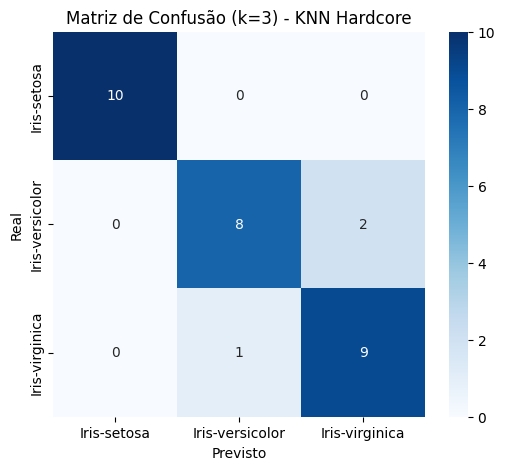

In [10]:
k = 3  # Escolha um número de vizinhos para a matriz de confusão

y_pred = knn_predict(X_train, y_train, X_test, k)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=y.unique(),
            yticklabels=y.unique())

plt.title(f"Matriz de Confusão (k={k}) - KNN Hardcore")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

### Visualização das métricas
Obs.: Acurácia e recall obtiveram os mesmos valores; por isso, a acurácia não foi exibida no gráfico.

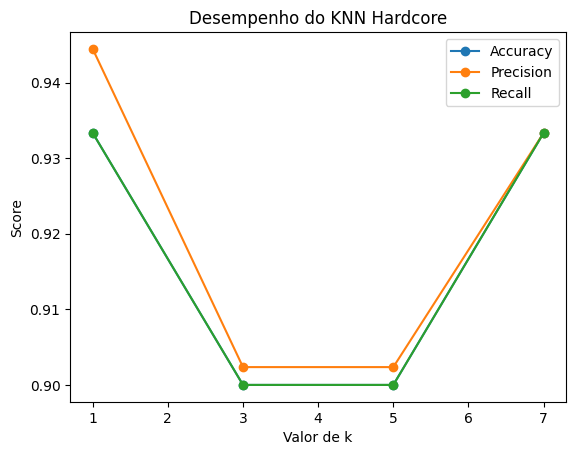

In [11]:
plt.figure()

plt.plot(results_df['k'], results_df['accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['k'], results_df['precision'], marker='o', label='Precision')
plt.plot(results_df['k'], results_df['recall'], marker='o', label='Recall')

plt.xlabel("Valor de k")
plt.ylabel("Score")
plt.title("Desempenho do KNN Hardcore")
plt.legend()

plt.show()

## Análise dos Resultados

Observa-se que o desempenho do KNN varia conforme o valor de k.

- Valores baixos de k (ex: k=1) podem causar overfitting
- Valores maiores suavizam a decisão, mas podem perder precisão
- O melhor valor de k pode ser identificado analisando as métricas

De forma geral, o modelo apresentou alta acurácia no dataset Iris, indicando boa separabilidade das classes.

📌 Overfitting explicação:
- Aprende muito bem os dados de treino
- Mas não generaliza bem para novos dados

👉 No KNN:
- k muito pequeno (ex: k=1) → tende a overfitting
- O modelo “decora” os dados ao invés de aprender padrões

# KNN com Sklearn
### Import do modelo

In [12]:
from sklearn.neighbors import KNeighborsClassifier

### Testando múltiplos valores de k

In [ ]:
k_values = [1, 3, 5, 7]
sklearn_results = []

for k in k_values:
    print(f"Rodando Sklearn KNN para k={k}...")
    
    # 1. Instancia o modelo fora da medição (apenas configuração de hiperparâmetros)
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # 2. Inicia o cronômetro de alta precisão
    start_time = time.perf_counter()
    
    # 3. Executa o "treinamento" (construção da árvore de busca) e a predição
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    # 4. Para o cronômetro
    end_time = time.perf_counter()
    
    # 5. Calcula a duração em milissegundos
    execution_time_ms = (end_time - start_time) * 1000
    
    # Cálculo das métricas (fora do escopo de tempo)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    sklearn_results.append({
        'k': k,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'time_ms': execution_time_ms
    })

print("\nResultados Sklearn:")
for r in sklearn_results:
    print(f"k={r['k']} -> Acc: {r['accuracy']:.2f}, Prec: {r['precision']:.2f}, Rec: {r['recall']:.2f}, Tempo: {r['time_ms']:.4f} ms")

Rodando Sklearn KNN para k=1...
Rodando Sklearn KNN para k=3...
Rodando Sklearn KNN para k=5...
Rodando Sklearn KNN para k=7...

Resultados Sklearn:
k=1 -> Acc: 0.93, Prec: 0.94, Rec: 0.93, Tempo: 9.8381 ms
k=3 -> Acc: 0.90, Prec: 0.90, Rec: 0.90, Tempo: 5.9816 ms
k=5 -> Acc: 0.90, Prec: 0.90, Rec: 0.90, Tempo: 6.0677 ms
k=7 -> Acc: 0.93, Prec: 0.93, Rec: 0.93, Tempo: 5.4608 ms


### Tabela Sklearn

In [14]:
sklearn_df = pd.DataFrame(sklearn_results)
sklearn_df

,k,accuracy,precision,recall,time_ms
0,1,0.933333,0.944444,0.933333,9.838136
1,3,0.900000,0.902357,0.900000,5.981604
2,5,0.900000,0.902357,0.900000,6.067674
3,7,0.933333,0.933333,0.933333,5.460776


### Matriz de confusão (Sklearn)

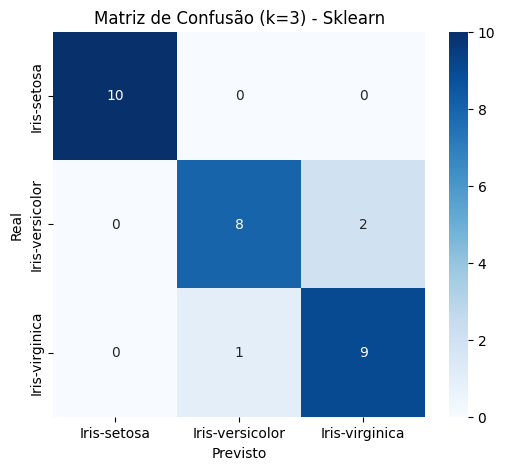

In [21]:
k = 3 # Escolha um número de vizinhos para a matriz de confusão

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=y.unique(),
            yticklabels=y.unique())

plt.title(f"Matriz de Confusão (k={k}) - Sklearn")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

### COMPARAÇÃO FINAL
Comparando métricas dos modelos Hardcore e Sklearn.

In [16]:
comparison_df = results_df.merge(sklearn_df, on='k', suffixes=('_hardcore', '_sklearn'))

# 1. Tabela isolada para Acurácia
df_acuracia = comparison_df[['k', 'accuracy_hardcore', 'accuracy_sklearn']]
print("--- Comparação de Acurácia ---")
display(df_acuracia)

# 2. Tabela isolada para Precisão
df_precisao = comparison_df[['k', 'precision_hardcore', 'precision_sklearn']]
print("\n--- Comparação de Precisão ---")
display(df_precisao)

# 3. Tabela isolada para Revocação
df_revocacao = comparison_df[['k', 'recall_hardcore', 'recall_sklearn']]
print("\n--- Comparação de Revocação ---")
display(df_revocacao)

# 4. Tabela isolada para Tempo
df_tempo = comparison_df[['k', 'time_ms_hardcore', 'time_ms_sklearn']] 
print("\n--- Comparação de Tempo de Execução ---")
display(df_tempo)

--- Comparação de Acurácia ---


,k,accuracy_hardcore,accuracy_sklearn
0,1,0.933333,0.933333
1,3,0.900000,0.900000
2,5,0.900000,0.900000
3,7,0.933333,0.933333



--- Comparação de Precisão ---


,k,precision_hardcore,precision_sklearn
0,1,0.944444,0.944444
1,3,0.902357,0.902357
2,5,0.902357,0.902357
3,7,0.933333,0.933333



--- Comparação de Revocação ---


,k,recall_hardcore,recall_sklearn
0,1,0.933333,0.933333
1,3,0.900000,0.900000
2,5,0.900000,0.900000
3,7,0.933333,0.933333



--- Comparação de Tempo de Execução ---


,k,time_ms_hardcore,time_ms_sklearn
0,1,642.290046,9.838136
1,3,755.546495,5.981604
2,5,637.302839,6.067674
3,7,710.214204,5.460776


### Visualização da comparação
Obs.: Hardcore e Sklearn obtiveram os mesmos valores; por isso, o Hardcore não foi exibido no gráfico.

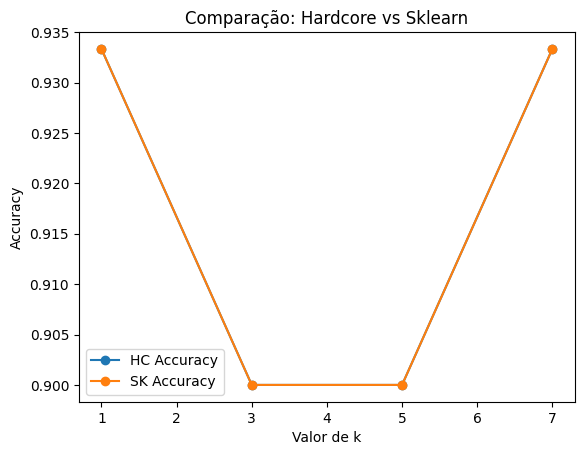

In [17]:
plt.figure()

plt.plot(comparison_df['k'], comparison_df['accuracy_hardcore'], marker='o', label='HC Accuracy')
plt.plot(comparison_df['k'], comparison_df['accuracy_sklearn'], marker='o', label='SK Accuracy')

plt.xlabel("Valor de k")
plt.ylabel("Accuracy")
plt.title("Comparação: Hardcore vs Sklearn")
plt.legend()

plt.show()

## Comparação entre as Implementações

Observando os resultados, podemos destacar:

- Ambas as implementações apresentam métricas muito semelhantes, indicando que o algoritmo foi corretamente implementado.
- A versão com Scikit-learn apresenta desempenho computacional superior, devido a otimizações internas.
- A implementação manual, embora mais lenta, permite melhor entendimento do funcionamento do algoritmo.

Além disso, a utilização do mesmo conjunto de treino e teste garante uma comparação justa entre os modelos.

## Conclusão

O algoritmo KNN mostrou-se eficiente para o dataset Iris. A implementação com Scikit-learn é mais indicada para aplicações práticas, enquanto a versão manual é ideal para fins educacionais.